# FIFA Player Data Analysis (2015–2021)

This project analyzes FIFA player datasets from 2015–2021 to understand player performance, club strength, nationality trends, and relationships between attributes like age, wage, and overall rating.

## Problem Statement

Football clubs invest millions in players. Understanding what factors influence player performance and value is important.

This project tries to answer:

• Which players have the highest ratings  
• Which countries produce the best players  
• Which clubs have the strongest squads  
• How age affects performance  
• Relationship between wage and rating

## Dataset Description

Source: FIFA Career Mode Dataset

Files Used:
- players_15.csv
- players_16.csv
- players_17.csv
- players_18.csv
- players_19.csv
- players_20.csv
- players_21.csv

## Project Workflow

This project follows a structured data analysis workflow:

1. Data Collection – Load FIFA datasets (2015–2021)
2. Data Cleaning – Handle missing values and select important features
3. Data Exploration – Understand data distribution
4. Exploratory Data Analysis – Analyze players, clubs, nationalities
5. Visualization – Create charts to identify patterns
6. Insights – Extract meaningful findings

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Dataset Path

In [4]:
path = r"C:\Users\hp\Downloads\fifa_data"

# Load Dataset

In [5]:
df15 = pd.read_csv(path + r"\players_15.csv")
df16 = pd.read_csv(path + r"\players_16.csv")
df17 = pd.read_csv(path + r"\players_17.csv")
df18 = pd.read_csv(path + r"\players_18.csv")
df19 = pd.read_csv(path + r"\players_19.csv")
df20 = pd.read_csv(path + r"\players_20.csv")
df21 = pd.read_csv(path + r"\players_21.csv")

# Combine Dataset

In [9]:
df = pd.concat([df15,df16,df17,df18,df19,df20,df21])

df.reset_index(drop=True,inplace=True)

df.shape

(122841, 106)

# Dataset Overview

In [10]:
df.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club_name,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,27,1987-06-24,169,67,Argentina,FC Barcelona,...,62+3,62+3,62+3,62+3,62+3,54+3,45+3,45+3,45+3,54+3
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,29,1985-02-05,185,80,Portugal,Real Madrid,...,63+3,63+3,63+3,63+3,63+3,57+3,52+3,52+3,52+3,57+3
2,9014,https://sofifa.com/player/9014/arjen-robben/15...,A. Robben,Arjen Robben,30,1984-01-23,180,80,Netherlands,FC Bayern München,...,64+3,64+3,64+3,64+3,64+3,55+3,46+3,46+3,46+3,55+3
3,41236,https://sofifa.com/player/41236/zlatan-ibrahim...,Z. Ibrahimović,Zlatan Ibrahimović,32,1981-10-03,195,95,Sweden,Paris Saint-Germain,...,61+3,65+3,65+3,65+3,61+3,56+3,55+3,55+3,55+3,56+3
4,167495,https://sofifa.com/player/167495/manuel-neuer/...,M. Neuer,Manuel Neuer,28,1986-03-27,193,92,Germany,FC Bayern München,...,36+3,40+3,40+3,40+3,36+3,36+3,38+3,38+3,38+3,36+3


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122841 entries, 0 to 122840
Columns: 106 entries, sofifa_id to rb
dtypes: float64(19), int64(43), object(44)
memory usage: 99.3+ MB


In [13]:
df.describe()

,sofifa_id,age,height_cm,weight_kg,league_rank,overall,potential,value_eur,wage_eur,international_reputation,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
count,122841.000000,122841.000000,122841.000000,122841.000000,121272.000000,122841.000000,122841.000000,1.228410e+05,122841.000000,122841.000000,...,122841.000000,91063.000000,85414.000000,122841.000000,122841.000000,122841.000000,122841.000000,122841.000000,122841.000000,122841.000000
mean,208516.528749,25.102441,181.191793,75.295593,1.378282,65.695753,70.671014,2.045513e+06,11235.054664,1.112560,...,48.888197,57.757574,45.025944,47.538900,45.609837,16.564274,16.304491,16.163830,16.308635,16.679610
std,34908.678726,4.644967,6.714110,6.985100,0.751320,7.093064,6.298466,4.885185e+06,22478.888064,0.389652,...,15.613346,12.420467,20.633722,21.370288,20.995487,17.696306,16.827434,16.436778,16.981201,18.001501
min,2.000000,16.000000,154.000000,49.000000,0.000000,40.000000,40.000000,0.000000e+00,0.000000,1.000000,...,5.000000,3.000000,3.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,193013.000000,21.000000,176.000000,70.000000,1.000000,61.000000,66.000000,2.500000e+05,2000.000000,1.000000,...,39.000000,50.000000,25.000000,26.000000,25.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,214330.000000,25.000000,181.000000,75.000000,1.000000,66.000000,70.000000,6.000000e+05,4000.000000,1.000000,...,50.000000,59.000000,49.000000,54.000000,51.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,231465.000000,28.000000,186.000000,80.000000,2.000000,70.000000,75.000000,1.600000e+06,10000.000000,1.000000,...,61.000000,66.000000,63.000000,66.000000,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,258970.000000,53.000000,208.000000,110.000000,4.000000,94.000000,95.000000,1.230000e+08,575000.000000,5.000000,...,96.000000,96.000000,94.000000,94.000000,95.000000,91.000000,92.000000,95.000000,91.000000,94.000000


# Select Important Columns

In [14]:
df = df[['short_name','age','nationality','club_name',
         'overall','potential','value_eur','wage_eur',
         'player_positions']]
df

,short_name,age,nationality,club_name,overall,potential,value_eur,wage_eur,player_positions
0,L. Messi,27,Argentina,FC Barcelona,93,95,100500000,550000,CF
1,Cristiano Ronaldo,29,Portugal,Real Madrid,92,92,79000000,375000,"LW, LM"
2,A. Robben,30,Netherlands,FC Bayern München,90,90,54500000,275000,"RM, LM, RW"
3,Z. Ibrahimović,32,Sweden,Paris Saint-Germain,90,90,52500000,275000,ST
4,M. Neuer,28,Germany,FC Bayern München,90,90,63500000,300000,GK
...,...,...,...,...,...,...,...,...,...
122836,K. Angulo,24,Colombia,América de Cali,47,52,40000,500,CM
122837,Zhang Mengxuan,21,China PR,Chongqing Dangdai Lifan FC SWM Team,47,52,35000,1000,CB
122838,Wang Zhenghao,20,China PR,Tianjin TEDA FC,47,51,35000,1000,CB
122839,Chen Zitong,23,China PR,Shijiazhuang Ever Bright F.C.,47,51,40000,1000,CM


# Missing Values

In [15]:
df.isnull().sum()

short_name             0
age                    0
nationality            0
club_name           1569
overall                0
potential              0
value_eur              0
wage_eur               0
player_positions       0
dtype: int64

In [17]:
df = df.dropna()
df

,short_name,age,nationality,club_name,overall,potential,value_eur,wage_eur,player_positions
0,L. Messi,27,Argentina,FC Barcelona,93,95,100500000,550000,CF
1,Cristiano Ronaldo,29,Portugal,Real Madrid,92,92,79000000,375000,"LW, LM"
2,A. Robben,30,Netherlands,FC Bayern München,90,90,54500000,275000,"RM, LM, RW"
3,Z. Ibrahimović,32,Sweden,Paris Saint-Germain,90,90,52500000,275000,ST
4,M. Neuer,28,Germany,FC Bayern München,90,90,63500000,300000,GK
...,...,...,...,...,...,...,...,...,...
122836,K. Angulo,24,Colombia,América de Cali,47,52,40000,500,CM
122837,Zhang Mengxuan,21,China PR,Chongqing Dangdai Lifan FC SWM Team,47,52,35000,1000,CB
122838,Wang Zhenghao,20,China PR,Tianjin TEDA FC,47,51,35000,1000,CB
122839,Chen Zitong,23,China PR,Shijiazhuang Ever Bright F.C.,47,51,40000,1000,CM


# Dataset Size

In [18]:
print("Total Rows:",df.shape[0])
print("Total Columns:",df.shape[1])

Total Rows: 121272
Total Columns: 9


# Top 10 Best Players

In [19]:
top_players = df.sort_values(by="overall",ascending=False).head(10)

top_players[['short_name','overall','club_name','nationality']]
top_players

,short_name,age,nationality,club_name,overall,potential,value_eur,wage_eur,player_positions
16155,L. Messi,28,Argentina,FC Barcelona,94,95,111000000,550000,"RW, CF"
67329,Cristiano Ronaldo,33,Portugal,Juventus,94,94,77000000,400000,"ST, LW"
67330,L. Messi,31,Argentina,FC Barcelona,94,94,110500000,575000,"CF, RW, ST"
31778,Cristiano Ronaldo,31,Portugal,Real Madrid,94,94,87000000,575000,"LW, LM, ST"
49375,Cristiano Ronaldo,32,Portugal,Real Madrid,94,94,95500000,575000,"LW, ST"
85414,L. Messi,32,Argentina,FC Barcelona,94,94,95500000,575000,"RW, CF, ST"
31779,L. Messi,29,Argentina,FC Barcelona,93,93,89000000,575000,RW
16156,Cristiano Ronaldo,30,Portugal,Real Madrid,93,93,85500000,475000,"LW, LM"
103897,L. Messi,33,Argentina,FC Barcelona,93,93,67500000,560000,"RW, ST, CF"
85415,Cristiano Ronaldo,34,Portugal,Juventus,93,93,58500000,400000,"ST, LW"


# Top 20 Players Bar Chart

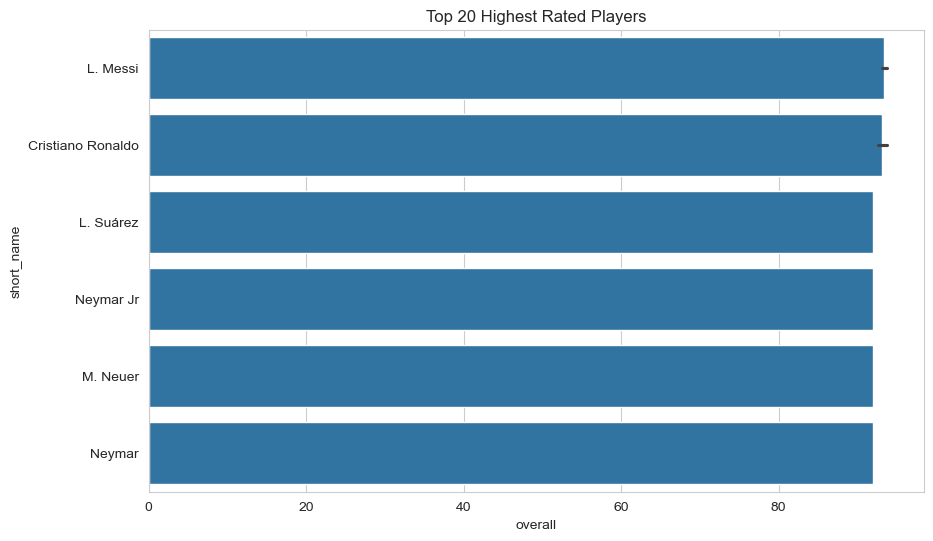

In [30]:
top20 = df.sort_values(by='overall',ascending=False).head(20)

plt.figure(figsize=(10,6))

sns.barplot(x='overall',y='short_name',data=top20)

plt.title("Top 20 Highest Rated Players")

plt.show()

# Age Distribution

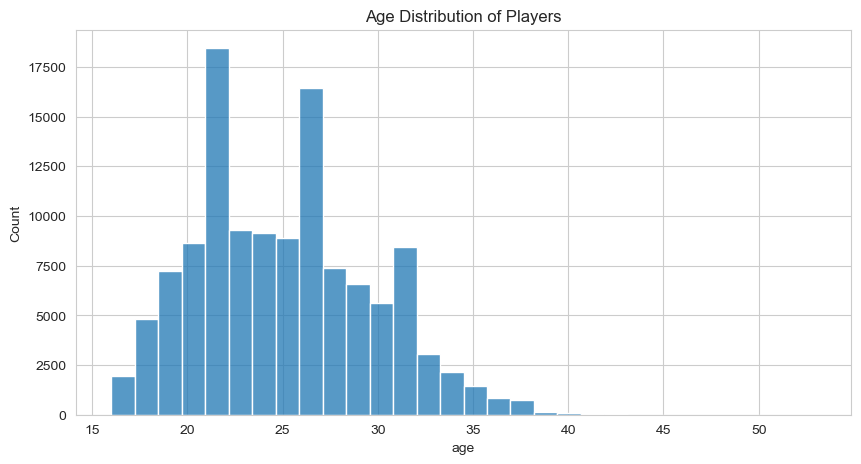

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(df['age'],bins=30)

plt.title("Age Distribution of Players")

plt.show()

# Top Nationalities

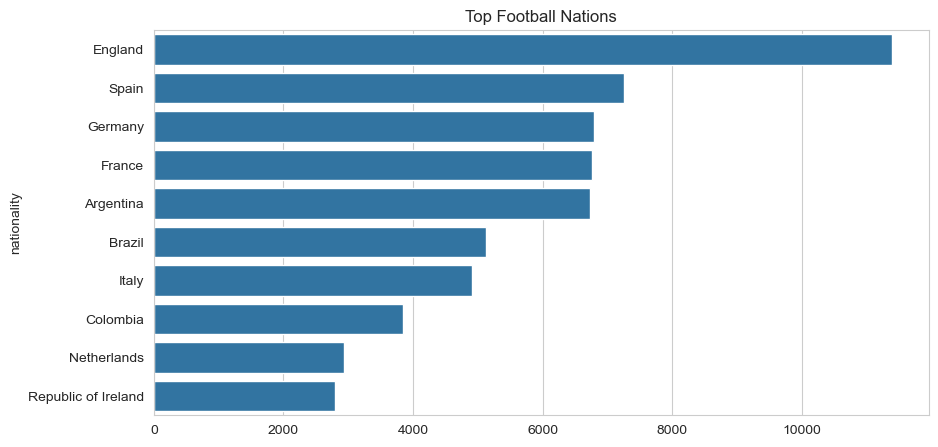

In [21]:
top_countries = df['nationality'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_countries.values,y=top_countries.index)

plt.title("Top Football Nations")

plt.show()

# Top Clubs

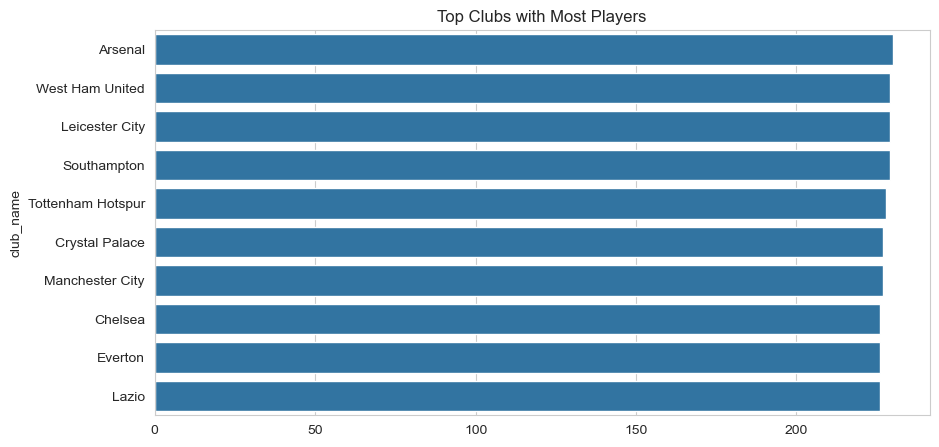

In [22]:
top_clubs = df['club_name'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_clubs.values,y=top_clubs.index)

plt.title("Top Clubs with Most Players")

plt.show()

# Wage vs Rating

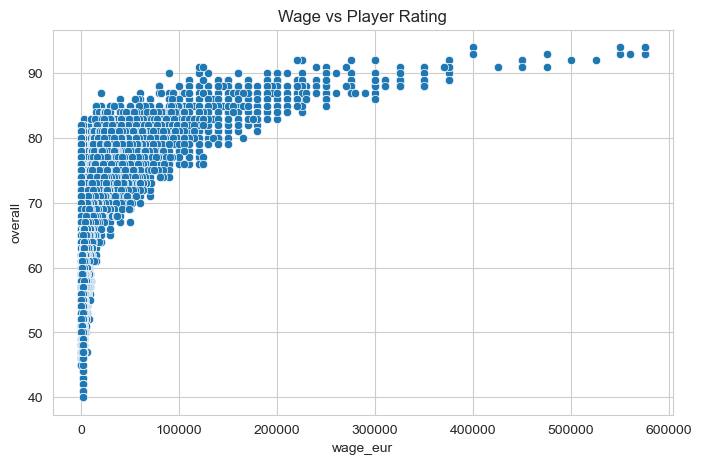

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='wage_eur',y='overall',data=df)

plt.title("Wage vs Player Rating")

plt.show()

# Most Valuable Players

In [24]:
top_value = df.sort_values(by="value_eur",ascending=False).head(10)

top_value[['short_name','value_eur','club_name','nationality']]

,short_name,value_eur,club_name,nationality
49377,Neymar,123000000,Paris Saint-Germain,Brazil
67331,Neymar,118500000,Paris Saint-Germain,Brazil
16155,L. Messi,111000000,FC Barcelona,Argentina
67330,L. Messi,110500000,FC Barcelona,Argentina
31780,Neymar,109000000,FC Barcelona,Brazil
103903,K. Mbappé,105500000,Paris Saint-Germain,France
85416,Neymar Jr,105500000,Paris Saint-Germain,Brazil
49376,L. Messi,105000000,FC Barcelona,Argentina
67333,K. De Bruyne,102000000,Manchester City,Belgium
0,L. Messi,100500000,FC Barcelona,Argentina


# Age vs Performance

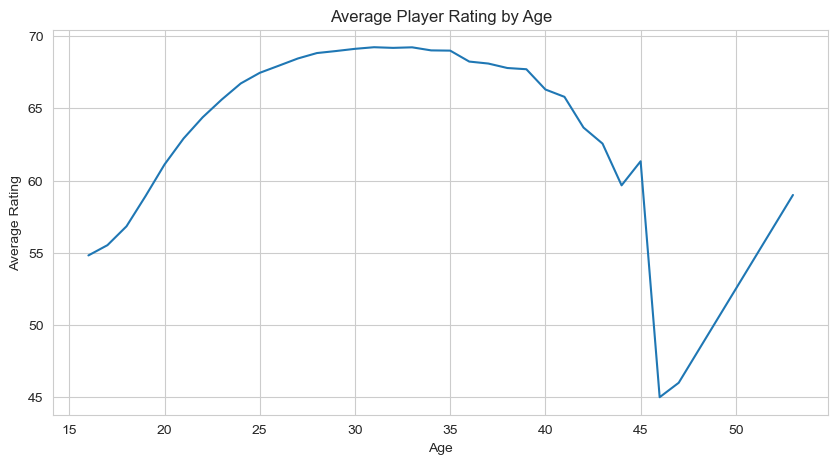

In [25]:
age_rating = df.groupby("age")["overall"].mean()

plt.figure(figsize=(10,5))

age_rating.plot()

plt.title("Average Player Rating by Age")

plt.xlabel("Age")

plt.ylabel("Average Rating")

plt.show()

# Age vs Rating Boxplot

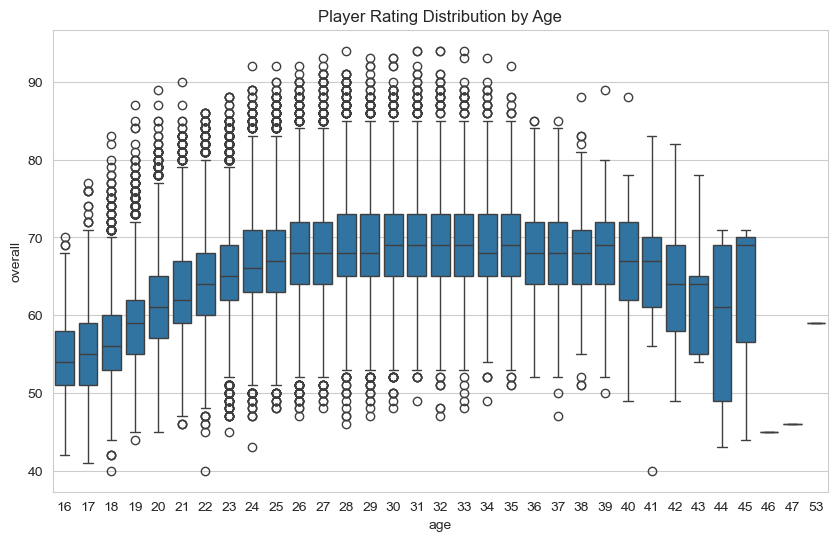

In [31]:
plt.figure(figsize=(10,6))

sns.boxplot(x='age',y='overall',data=df)

plt.title("Player Rating Distribution by Age")

plt.show()

# Correlation Heatmap

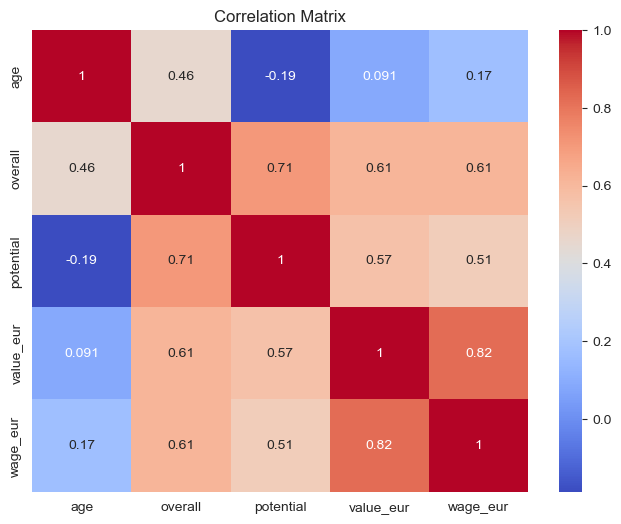

In [26]:
plt.figure(figsize=(8,6))

sns.heatmap(df[['age','overall','potential','value_eur','wage_eur']].corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

# Pairplot

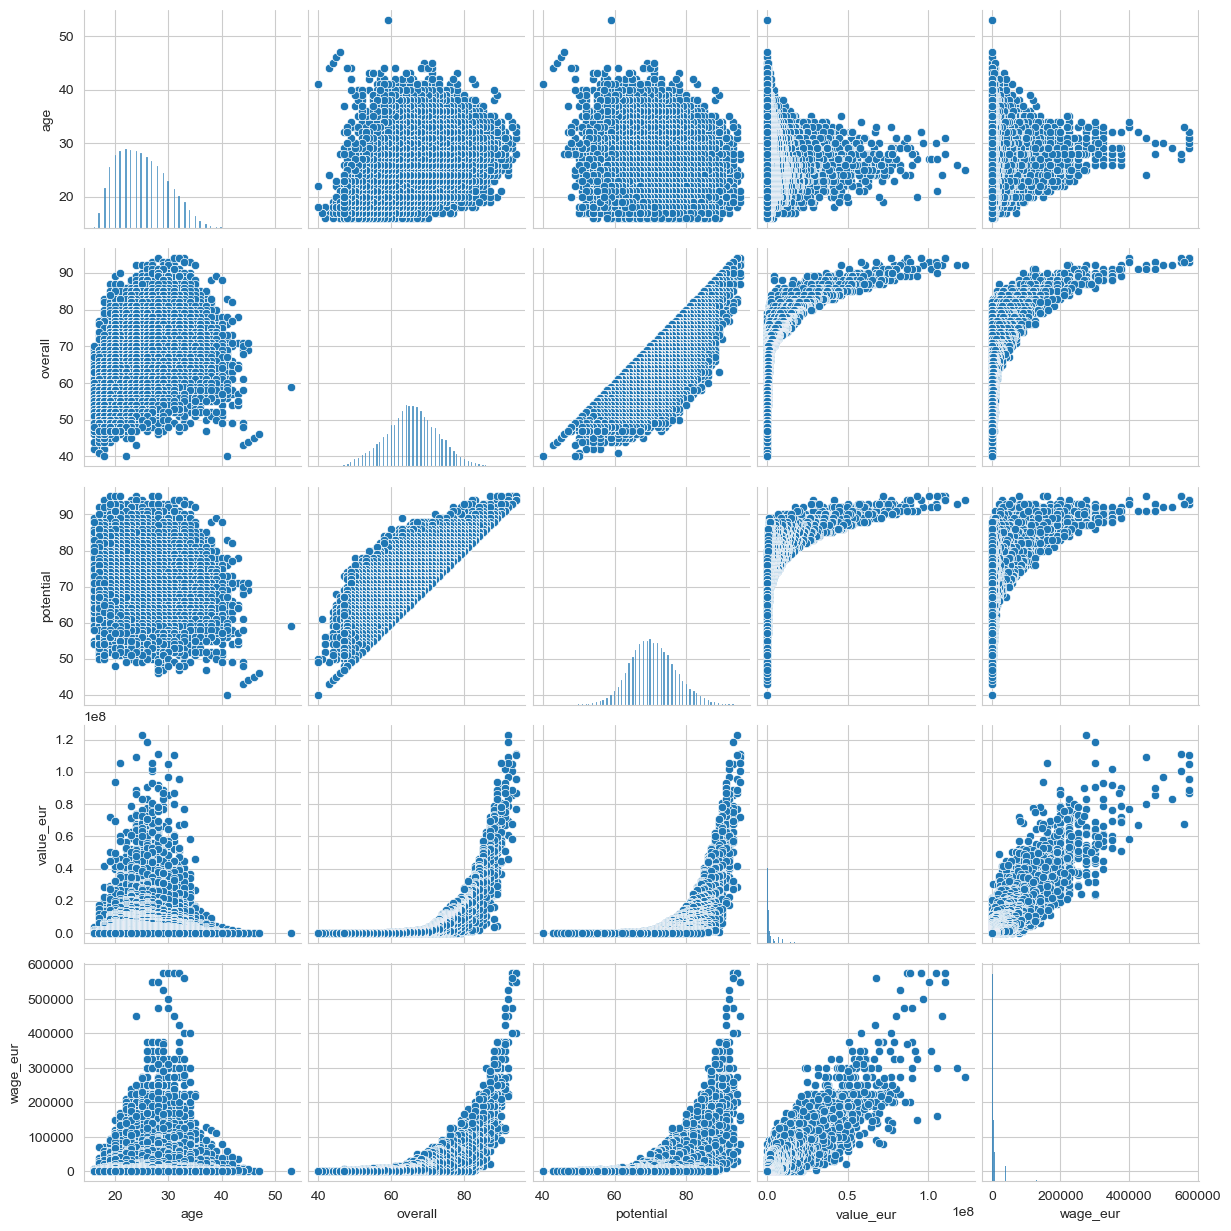

In [27]:
sns.pairplot(df[['age','overall','potential','value_eur','wage_eur']])

plt.show()

# Top Positions

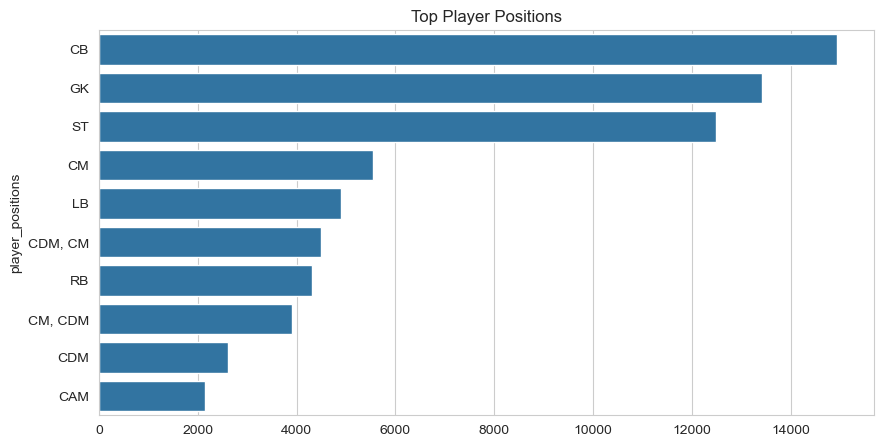

In [28]:
top_positions = df['player_positions'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_positions.values,y=top_positions.index)

plt.title("Top Player Positions")

plt.show()

# Market Value Distribution

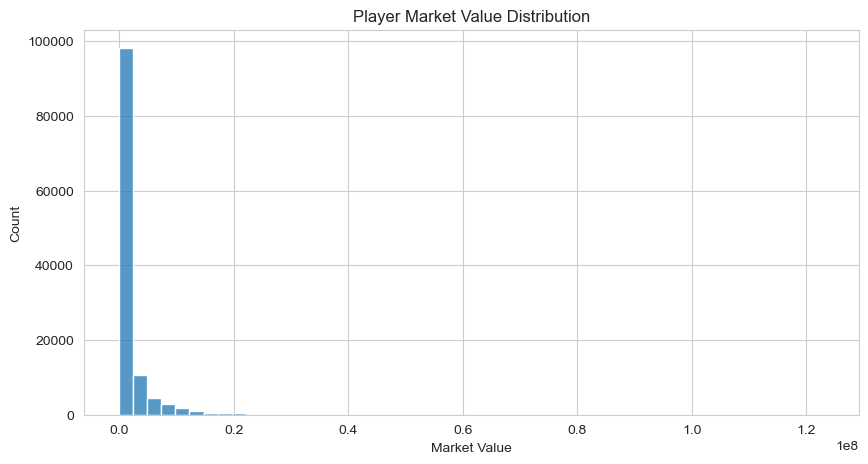

In [29]:
plt.figure(figsize=(10,5))

sns.histplot(df['value_eur'],bins=50)

plt.title("Player Market Value Distribution")

plt.xlabel("Market Value")

plt.ylabel("Count")

plt.show()

## Key Insights

• Player performance peaks between age 25–29  
• European countries dominate football talent  
• Higher wage players usually have higher ratings  
• Most players have relatively low market value  

## Business Recommendations

Based on the analysis:

• Clubs should invest in players aged 24–29 since performance peaks in this range.

• High wage players generally have higher ratings, so wage can be used as an indicator of player value.

• European leagues dominate talent production, so scouting efforts can focus there.

## Conclusion

This analysis explored FIFA player datasets from 2015–2021.

Key findings:

• Player rating correlates with wages and market value  
• European football dominates global talent  
• Players reach peak performance in their mid-20s

Future Work:

• Player performance prediction  
• Transfer value prediction using machine learning